---
title: Splits Testing
author: Fedor Pavlov
date: 2026-03-23
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

A clone of Fedor Pavlov's code on `splits_testing.py` (deprecated, check previous versions of the branch), made by Andrei Akopian for some testing and image exports.

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic
from sklearn.ensemble import RandomForestRegressor

In [41]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

from src.utils import helper_functions

## Loading the Data

In [42]:
LAB_DATA = "../../../data/useful_columns_data.csv"
ATMO_DATA = "../../../data/isprs_26_only_vza_rows.csv"

In [43]:
df = helper_functions.open_file(LAB_DATA)
fractions, nr900to1700_raw = helper_functions.take_subset(df,start=900,end=1700)
# fractions = fractions[["npv_fraction"], ["soil_fraction"]]  # for atmo data

In [44]:
# Normalization (L1)
dataset = nr900to1700_raw
# norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()  # L2 Norm
norms = dataset.sum(axis=1).to_numpy() # L1 Norm
print(norms.min(), norms.max())
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
# post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
post_norms = normalized_dataset.sum(axis=1)
print(post_norms.min(), post_norms.max())
nr900to1700 = normalized_dataset

8.705963602199999 45.08746808780001
0.9999999999999989 1.0000000000000013


In [45]:
x = nr900to1700
y = fractions.to_numpy()

In [46]:
x

array([[0.01030187, 0.01038297, 0.01048805, ..., 0.01384943, 0.01381653,
        0.01380659],
       [0.00978473, 0.00987716, 0.00999493, ..., 0.01422971, 0.01419182,
        0.01418741],
       [0.01033747, 0.01042332, 0.0105402 , ..., 0.01396935, 0.01392425,
        0.01390817],
       ...,
       [0.01843781, 0.01845859, 0.01850286, ..., 0.00713524, 0.00706463,
        0.00694277],
       [0.01550707, 0.01558504, 0.01565736, ..., 0.00912113, 0.00901789,
        0.00883788],
       [0.01757526, 0.01763743, 0.01770921, ..., 0.00751754, 0.0074259 ,
        0.00727569]], shape=(1723, 81))

## Performing the Splits

In [ ]:
#spliting the data
def k_split_dataset(X: int, Y: int, train_size_percentage: int) -> list[list[list]]:
    
    kfold = KFold(n_splits=train_size_percentage, shuffle= True, random_state=42)

    ids = range(len(X))
    train_ids = np.array([])
    test_ids = np.array([])
    data = []
    for train, test  in kfold.split(ids):
        train_ids = np.array([])
        test_ids = np.array([])
        x_train = []
        x_test = [] 
        y_train = []  
        y_test = []
        train_ids = np.append(train,train_ids)
        test_ids = np.append(test,test_ids)
        for i in train_ids.astype(int):

            x_train.append(x[i])
            y_train.append(y[i])
        for i in test_ids.astype(int):
            x_test.append(x[i])
            y_test.append(y[i])
        data.append([x_train, x_test, y_train, y_test])
    return data

def get_all_splits(first: int, last: int) -> list:
    ar = []
    for k in range(first, last):
        ar.append(k_split_dataset(x,y,k))
    return ar

def find_the_most_optimal_k_splits(all_splits: list[int]) -> list[float]:
    r2s = []
    splitnum = 2
    for i in all_splits:
        bestr2 = -1
        bestrmse = -1
        best_y_test = []
        best_y_predict = []
        for j in i:
                #splitting the dataset
            X_train, X_test, y_train, y_test = j[0], j[1], j[2], j[3]
                #choosing regression type and training
            regr = RandomForestRegressor(random_state=42)
            regr.fit(X_train, y_train)
            y_predict = regr.predict(X_test)
                #getting results
            r2 = r2_score(y_test,y_predict)
            if r2> bestr2:
                bestr2 = r2
                best_y_test = y_test
                best_y_predict = y_predict
            print(f"split size: {splitnum}, r2: {str(r2)}")
        # print(len(X_train), len(X_test))
        r2s.append(bestr2)
        splitnum+=1
    return r2s

def find_the_most_optimal_randomsplit() -> list[float]:
    r2s = []
    for i in range(10,100,5):
        X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=1-i/100, train_size=i/100, random_state=42)
        regr = RandomForestRegressor(random_state=42)
        regr.fit(X_train, y_train)
        y_predict = regr.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_predict)
        r2 = r2_score(y_test,y_predict)
        r2s.append(r2)
        print("train_size: "+str(i)+"%, r2: "+str(r2)+", rmse: "+str(rmse))
    return r2s

In [48]:
#orig_scores = cross_validation_scores(x,y,len(x)//10)
all_splits = get_all_splits(2, 20)

## Visualization

In [49]:
def create_r2s_plot(r2s: list[float], title: str = "Mean $R^2$ vs Train Size", savepath: str | None = "split_testing.svg") -> None:
    """
    Create a graph of r^2s vs split size.
    """
    plt.rcParams["font.family"] = "Times New Roman"
    csfont = {'fontname':'Times New Roman'}
    plt.figure(figsize=(3, 5))  # change plot dimensions here
    plt.plot(range(10,100,5),r2s)
    plt.title(title, **csfont)
    plt.xlabel("Train Size (%)", **csfont)
    plt.ylabel("$R^2$", **csfont)
    plt.xticks(range(0,100+1, 10))
    plt.grid(True)
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, format='svg')
    plt.show()

In [50]:
# takes ~30 minutes to run
r2s_kfold_splits = find_the_most_optimal_k_splits(all_splits)

train_size: 0.11, r2: 0.813644199568396
train_size: 0.11, r2: 0.8177935469437644
train_size: 0.17, r2: 0.8290887086421197
train_size: 0.17, r2: 0.8343184158003719
train_size: 0.17, r2: 0.8368808924462187
train_size: 0.22, r2: 0.8119748619565081
train_size: 0.22, r2: 0.8493328620172967
train_size: 0.22, r2: 0.8403995202253411
train_size: 0.22, r2: 0.8462218750175117
train_size: 0.28, r2: 0.8128153876907279
train_size: 0.28, r2: 0.8462819499532938
train_size: 0.28, r2: 0.8308454092246732
train_size: 0.28, r2: 0.8573314108014144
train_size: 0.28, r2: 0.841461437516536
train_size: 0.33, r2: 0.8190190570817436
train_size: 0.33, r2: 0.8432891472644904
train_size: 0.33, r2: 0.8444828303601288
train_size: 0.33, r2: 0.8455556992354065
train_size: 0.33, r2: 0.837883114836703
train_size: 0.33, r2: 0.8464443166972293
train_size: 0.39, r2: 0.8241997722240999
train_size: 0.39, r2: 0.8156140656562668
train_size: 0.39, r2: 0.8678297254662981
train_size: 0.39, r2: 0.8117997142695167
train_size: 0.39, r

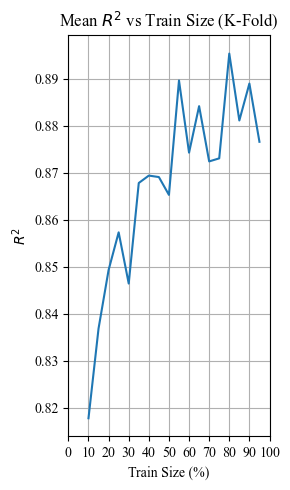

In [51]:
create_r2s_plot(r2s_kfold_splits, title="Mean $R^2$ vs Train Size (K-Fold)", savepath="kfold_splits_testing.svg")

In [52]:
# takes <2 minutes to run on a modern laptop
r2s_random_splits = find_the_most_optimal_randomsplit()

train_size: 10%, r2: 0.6985166210676392, rmse: 0.16605803201013972
train_size: 15%, r2: 0.7379459514906076, rmse: 0.1550829768979597
train_size: 20%, r2: 0.7598880242095087, rmse: 0.14858901505721808
train_size: 25%, r2: 0.7581573724079517, rmse: 0.1498510646499428
train_size: 30%, r2: 0.7789329708655091, rmse: 0.14359923590143572
train_size: 35%, r2: 0.7934557729187182, rmse: 0.13912212318346873
train_size: 40%, r2: 0.7963288603543587, rmse: 0.13852857685298745
train_size: 45%, r2: 0.8027075258612144, rmse: 0.13582294901088518
train_size: 50%, r2: 0.8025707609102181, rmse: 0.13569295650064184
train_size: 55%, r2: 0.8049021791464587, rmse: 0.13542773986789983
train_size: 60%, r2: 0.8091227490833903, rmse: 0.1343993063337914
train_size: 65%, r2: 0.8233619041967454, rmse: 0.12876744765793088
train_size: 70%, r2: 0.8244060394875691, rmse: 0.1277343722666251
train_size: 75%, r2: 0.8168205526754818, rmse: 0.12960694996096486
train_size: 80%, r2: 0.8160714647855709, rmse: 0.13119194860268632

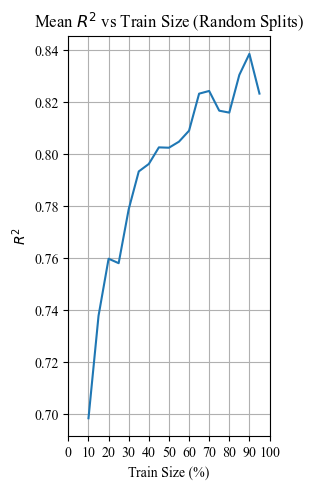

In [53]:
create_r2s_plot(r2s_random_splits, title="Mean $R^2$ vs Train Size (Random Splits)", savepath="random_split_tests.svg")